In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset (encoding='latin1' zaroori hai kyunki isme special characters hain)
df = pd.read_csv('IMDb Movies India.csv', encoding='latin1')

# Display first 5 rows
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.2 MB


In [4]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [5]:
# Drop rows where 'Rating' is missing (yeh humara target hai, isliye zaroori hai)
df = df.dropna(subset=['Rating'])

print("Shape after dropping missing ratings:", df.shape)

Shape after dropping missing ratings: (7919, 10)


In [6]:
# Clean 'Year' column - remove brackets and convert to numeric
df['Year'] = df['Year'].astype(str).str.extract('(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

print(df['Year'].head())

1    2019
3    2019
5    1997
6    2005
8    2012
Name: Year, dtype: int64


<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Asus\AppData\Local\Temp\ipykernel_12520\3841337183.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Year'] = df['Year'].astype(str).str.extract('(\d{4})')


In [7]:
# Clean 'Duration' column - remove ' min' and convert to numeric
df['Duration'] = df['Duration'].astype(str).str.extract('(\d+)')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

print(df['Duration'].head())

1    109.0
3    110.0
5    147.0
6    142.0
8     82.0
Name: Duration, dtype: float64


<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Asus\AppData\Local\Temp\ipykernel_12520\365722304.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Duration'] = df['Duration'].astype(str).str.extract('(\d+)')


In [8]:
# Clean 'Votes' column - remove commas and convert to numeric
df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

print(df['Votes'].head())

1       8
3      35
5     827
6    1086
8     326
Name: Votes, dtype: int64


In [9]:
df.isnull().sum()

Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64

In [10]:
# Fill missing 'Duration' with median
df['Duration'] = df['Duration'].fillna(df['Duration'].median())

# Fill missing 'Genre' with mode (most common genre)
df['Genre'] = df['Genre'].fillna(df['Genre'].mode()[0])

# Fill missing 'Director' with 'Unknown'
df['Director'] = df['Director'].fillna('Unknown')

# Fill missing 'Actor 1', 'Actor 2', 'Actor 3' with 'Unknown'
df['Actor 1'] = df['Actor 1'].fillna('Unknown')
df['Actor 2'] = df['Actor 2'].fillna('Unknown')
df['Actor 3'] = df['Actor 3'].fillna('Unknown')

# Verify no missing values remain
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [11]:
# Keep only the first genre if multiple genres are listed
df['Genre'] = df['Genre'].apply(lambda x: x.split(',')[0].strip())

print(df['Genre'].value_counts().head(10))

Genre
Drama          2634
Action         2306
Comedy         1190
Crime           343
Romance         279
Horror          188
Adventure       160
Documentary     143
Thriller        138
Musical         121
Name: count, dtype: int64


In [12]:
# One-Hot Encode Genre (kyunki genres limited hain)
df = pd.get_dummies(df, columns=['Genre'], drop_first=True)

print("Shape after Genre encoding:", df.shape)

Shape after Genre encoding: (7919, 28)


In [13]:
# Target Encoding: har Director/Actor ki average rating nikaalo
director_avg_rating = df.groupby('Director')['Rating'].mean()
actor1_avg_rating = df.groupby('Actor 1')['Rating'].mean()
actor2_avg_rating = df.groupby('Actor 2')['Rating'].mean()
actor3_avg_rating = df.groupby('Actor 3')['Rating'].mean()

# Naye columns banao jisme yeh average ratings hon
df['Director_Encoded'] = df['Director'].map(director_avg_rating)
df['Actor1_Encoded'] = df['Actor 1'].map(actor1_avg_rating)
df['Actor2_Encoded'] = df['Actor 2'].map(actor2_avg_rating)
df['Actor3_Encoded'] = df['Actor 3'].map(actor3_avg_rating)

df[['Director', 'Director_Encoded', 'Actor 1', 'Actor1_Encoded']].head()

,Director,Director_Encoded,Actor 1,Actor1_Encoded
1,Gaurav Bakshi,7.000000,Rasika Dugal,6.850000
3,Ovais Khan,4.400000,Prateik,5.420000
5,Rahul Rawail,5.358824,Bobby Deol,4.788889
6,Shoojit Sircar,7.500000,Jimmy Sheirgill,5.356000
8,Allyson Patel,5.600000,Yash Dave,5.600000


In [14]:
# Drop original text columns (unnecessary now)
df = df.drop(['Name', 'Director', 'Actor 1', 'Actor 2', 'Actor 3'], axis=1)

df.head()

,Year,Duration,Rating,Votes,Genre_Adventure,Genre_Animation,Genre_Biography,Genre_Comedy,Genre_Crime,Genre_Documentary,...,Genre_Mystery,Genre_Romance,Genre_Sci-Fi,Genre_Sport,Genre_Thriller,Genre_War,Director_Encoded,Actor1_Encoded,Actor2_Encoded,Actor3_Encoded
1,2019,109.0,7.0,8,False,False,False,False,False,False,...,False,False,False,False,False,False,7.000000,6.850000,7.000000,7.000000
3,2019,110.0,4.4,35,False,False,False,True,False,False,...,False,False,False,False,False,False,4.400000,5.420000,4.400000,4.450000
5,1997,147.0,4.7,827,False,False,False,True,False,False,...,False,False,False,False,False,False,5.358824,4.788889,5.786667,5.846154
6,2005,142.0,7.4,1086,False,False,False,False,False,False,...,False,False,False,False,False,False,7.500000,5.356000,6.050000,6.500000
8,2012,82.0,5.6,326,False,False,False,False,False,False,...,False,False,False,False,False,False,5.600000,5.600000,5.883333,5.600000


In [15]:
df.isnull().sum()

Year                 0
Duration             0
Rating               0
Votes                0
Genre_Adventure      0
Genre_Animation      0
Genre_Biography      0
Genre_Comedy         0
Genre_Crime          0
Genre_Documentary    0
Genre_Drama          0
Genre_Family         0
Genre_Fantasy        0
Genre_History        0
Genre_Horror         0
Genre_Music          0
Genre_Musical        0
Genre_Mystery        0
Genre_Romance        0
Genre_Sci-Fi         0
Genre_Sport          0
Genre_Thriller       0
Genre_War            0
Director_Encoded     0
Actor1_Encoded       0
Actor2_Encoded       0
Actor3_Encoded       0
dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

# Features (X) aur Target (y) alag karo
X = df.drop('Rating', axis=1)
y = df['Rating']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (6335, 26)
Testing set size: (1584, 26)


In [17]:
from sklearn.linear_model import LinearRegression

# Model banao aur train karo
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predictions karo test data pe
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.4961025160638776
Root Mean Squared Error (RMSE): 0.6757588392218445
R² Score: 0.7543763535166316


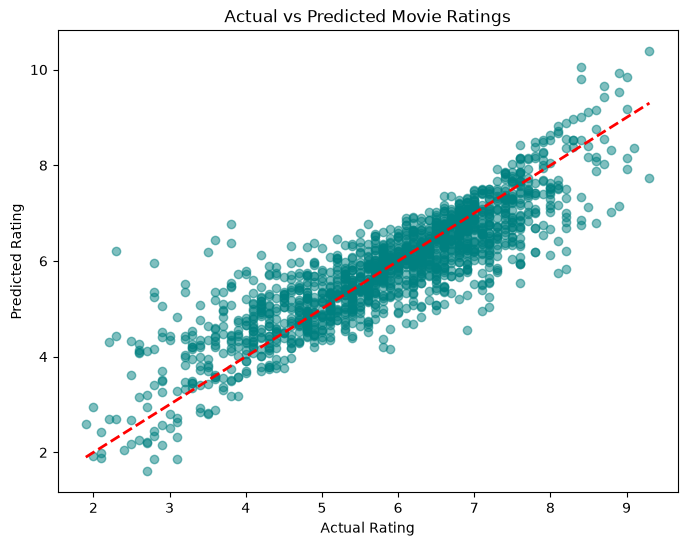

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Movie Ratings')
plt.show()

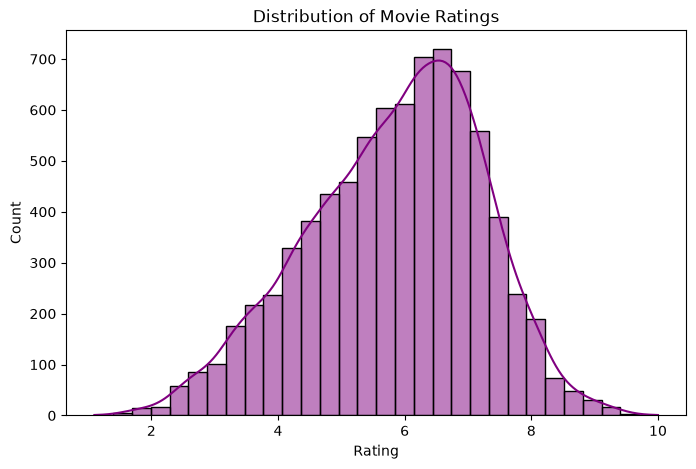

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=30, kde=True, color='purple')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.show()

In [21]:
# Feature coefficients dekhna
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(importance.head(10))

              Feature  Coefficient
22   Director_Encoded     0.455936
25     Actor3_Encoded     0.307145
23     Actor1_Encoded     0.276507
24     Actor2_Encoded     0.266622
11      Genre_Fantasy     0.229888
8   Genre_Documentary     0.224535
7         Genre_Crime     0.191115
20     Genre_Thriller     0.144799
13       Genre_Horror     0.112252
17      Genre_Romance     0.096606


## Conclusion

- A Linear Regression model was built to predict movie ratings based on Genre, Director, and Actors.
- The model achieved an R² score of **0.75**, indicating it explains 75% of the variance in movie ratings.
- Director and lead actors' historical average ratings were found to be strong predictors of a movie's rating.
- Missing values in Duration, Genre, Director, and Actor columns were handled through imputation and encoding techniques.